<a href="https://colab.research.google.com/github/Pragzz05/Heart-Disease-Prediction-using-Multiple-Machine-Learning-Algorithms/blob/main/models/ML_modelcomparison80_20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
df = pd.read_csv('/content/drive/MyDrive/Ml_data_set/HeartDiseaseTrain-Test.csv')  # upload your dataset

df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholestoral,fasting_blood_sugar,rest_ecg,Max_heart_rate,exercise_induced_angina,oldpeak,slope,vessels_colored_by_flourosopy,thalassemia,target
0,52,Male,Typical angina,125,212,Lower than 120 mg/ml,ST-T wave abnormality,168,No,1.0,Downsloping,Two,Reversable Defect,0
1,53,Male,Typical angina,140,203,Greater than 120 mg/ml,Normal,155,Yes,3.1,Upsloping,Zero,Reversable Defect,0
2,70,Male,Typical angina,145,174,Lower than 120 mg/ml,ST-T wave abnormality,125,Yes,2.6,Upsloping,Zero,Reversable Defect,0
3,61,Male,Typical angina,148,203,Lower than 120 mg/ml,ST-T wave abnormality,161,No,0.0,Downsloping,One,Reversable Defect,0
4,62,Female,Typical angina,138,294,Greater than 120 mg/ml,ST-T wave abnormality,106,No,1.9,Flat,Three,Fixed Defect,0


In [33]:
X = df.drop('target', axis=1)
y = df['target']

# Identify categorical columns for one-hot encoding
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)



In [35]:
rf = RandomForestClassifier(n_estimators=200)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

In [36]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

In [37]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)

In [38]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
import numpy as np

dt = DecisionTreeClassifier() # Initialize Decision Tree Classifier

# Define the models dictionary
models = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'SVM': svm,
    'KNN': knn,
    'Naive Bayes': nb
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, acc, prec, rec, f1, rmse])

In [40]:
results_df = pd.DataFrame({
    'Model': [item[0] for item in results], # Extract model names from the results list
    'Accuracy': [item[1] for item in results] # Extract accuracy values from the results list
})

print(results_df.sort_values(by='Accuracy', ascending=False))

                 Model  Accuracy
1        Decision Tree  0.985366
2        Random Forest  0.985366
4                  KNN  0.863415
3                  SVM  0.863415
0  Logistic Regression  0.795122
5          Naive Bayes  0.678049


In [42]:
best_model = results_df.sort_values(by='Accuracy', ascending=False).iloc[0]
print("Best Model:", best_model['Model'])
print("Best Accuracy:", best_model['Accuracy'])

Best Model: Decision Tree
Best Accuracy: 0.9853658536585366


In [43]:
#comparison table
import pandas as pd

results_df = pd.DataFrame(results, columns=[
    "Model", "Accuracy", "Precision", "Recall", "F1 Score", "RMSE"
])

# Sort by best accuracy
results_df = results_df.sort_values(by="Accuracy", ascending=False)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score      RMSE
1        Decision Tree  0.985366   1.000000  0.970874  0.985222  0.120972
2        Random Forest  0.985366   1.000000  0.970874  0.985222  0.120972
4                  KNN  0.863415   0.837838  0.902913  0.869159  0.369575
3                  SVM  0.863415   0.837838  0.902913  0.869159  0.369575
0  Logistic Regression  0.795122   0.769912  0.844660  0.805556  0.452635
5          Naive Bayes  0.678049   0.620915  0.922330  0.742188  0.567407


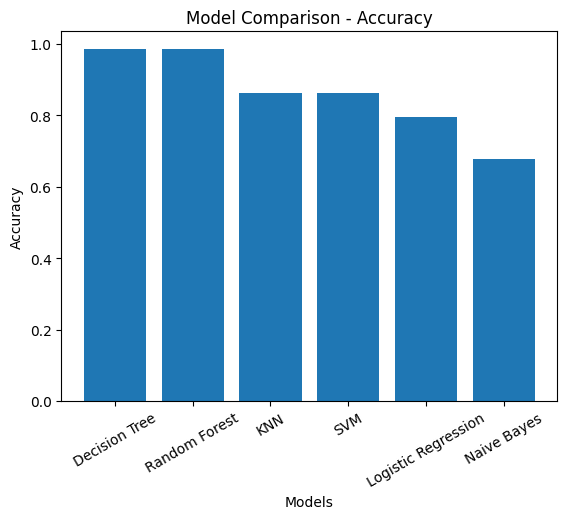

In [44]:
#accuracy comparion graph
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison - Accuracy")
plt.xticks(rotation=30)
plt.show()

Index(['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'RMSE'], dtype='object')


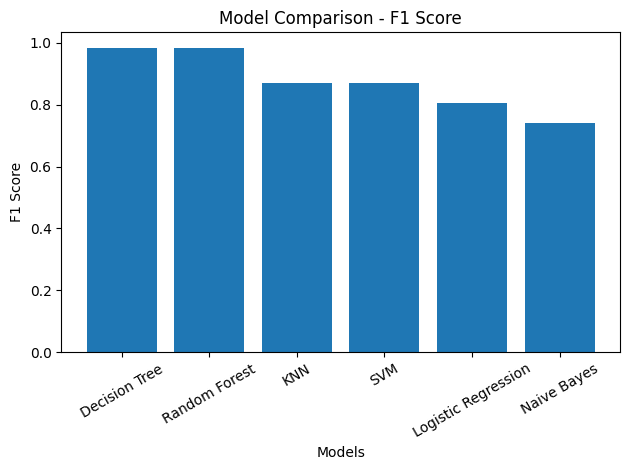

In [45]:
#f1 score grapgh
import matplotlib.pyplot as plt

# Check column names (important debug step)
print(results_df.columns)

plt.figure()
plt.bar(results_df["Model"], results_df["F1 Score"])

plt.xlabel("Models")
plt.ylabel("F1 Score")
plt.title("Model Comparison - F1 Score")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

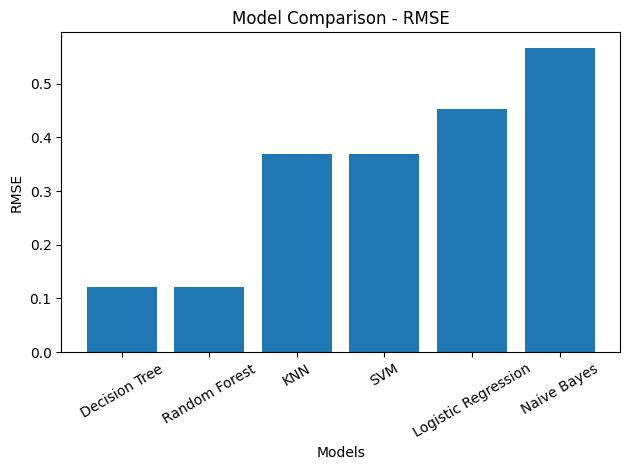

In [46]:
#rmse grapgh
import matplotlib.pyplot as plt

plt.figure()

plt.bar(results_df["Model"], results_df["RMSE"].values)

plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

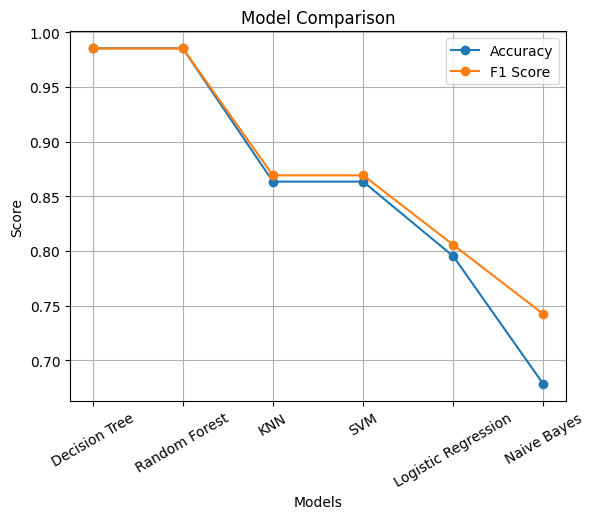

In [47]:
#combined line ghaps
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(results_df["Model"]))

plt.figure()

plt.plot(x, results_df["Accuracy"].values, marker='o', label="Accuracy")
plt.plot(x, results_df["F1 Score"].values, marker='o', label="F1 Score")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Comparison")

plt.xticks(x, results_df["Model"], rotation=30)

plt.legend()
plt.grid()

plt.show()

**Confusion Matrix**

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[44 58]
 [ 8 95]]


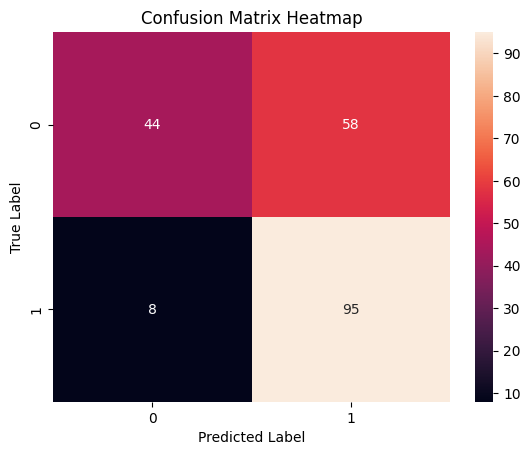

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")

plt.show()

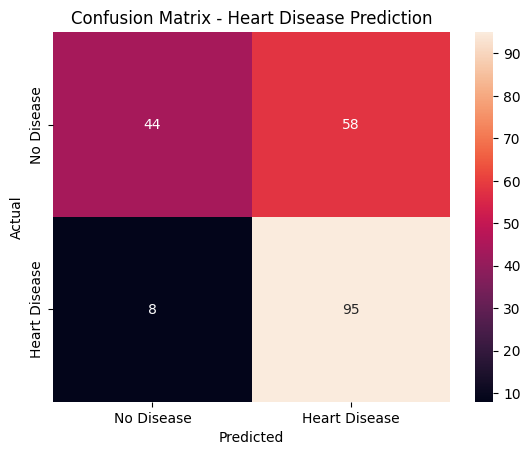

In [50]:
labels = ["No Disease", "Heart Disease"]

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Heart Disease Prediction")

plt.show()